In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [95]:
def percentDiff(x1,x2):
    return abs(x1 - x2)/abs(x1) * 100

In [113]:
simulation_results.Sample.to_numpy().min()

0

In [99]:
simulation_results = pd.read_csv("transmonCapMat_simulation_results.csv")

# Compare reference and machine learning predicted design results

Text(0, 0.5, 'Percent different [%]')

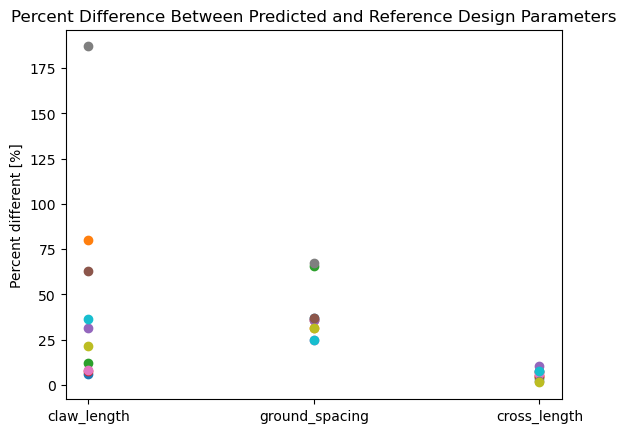

In [100]:
fig,ax = plt.subplots()
x = ["claw_length","ground_spacing","cross_length"]

for sample in range(len(simulation_results)):
    predicted_design = eval(simulation_results[simulation_results.Sample == sample].pred_design.iloc[0])
    reference_design = eval(simulation_results[simulation_results.Sample == sample].ref_design.iloc[0])
    
    y = []
    for pred,ref in zip(predicted_design.values(),reference_design.values()): 
        diff = percentDiff(float(ref[:-2]),float(pred[:-2]))
        y.append(diff)

    plt.scatter(x,y)

plt.title("Percent Difference Between Predicted and Reference Design Parameters")
plt.ylabel("Percent different [%]")

# Compare reference and machine learning Hamiltonian parameters
* Hamiltonian parameters calculated from electrostatic simulation results of reference/predicted design

Text(0, 0.5, 'Percent Difference between ref and pred H params [%]')

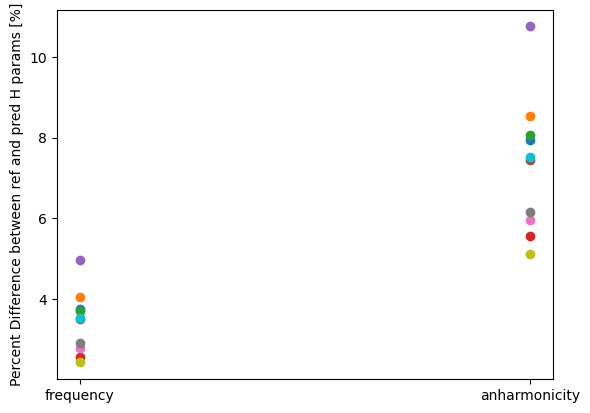

In [127]:
fig,ax = plt.subplots()
for sample in range(len(simulation_results)):
    predicted_f = eval(simulation_results[simulation_results.Sample == sample].pred_H_params.iloc[0])["qubit_frequency_GHz"]
    reference_f = eval(simulation_results[simulation_results.Sample == sample].ref_H_params.iloc[0])["qubit_frequency_GHz"]

    predicted_alpha = eval(simulation_results[simulation_results.Sample == sample].pred_H_params.iloc[0])["anharmonicity_MHz"]
    reference_alpha = eval(simulation_results[simulation_results.Sample == sample].ref_H_params.iloc[0])["anharmonicity_MHz"]

    diff_f = percentDiff(reference_f,predicted_f)
    diff_alpha = percentDiff(reference_alpha,predicted_alpha)
    
    plt.scatter(["frequency","anharmonicity"],[diff_f,diff_alpha])

plt.ylabel("Percent Difference between ref and pred H params [%]")
    

# Compare by Sample

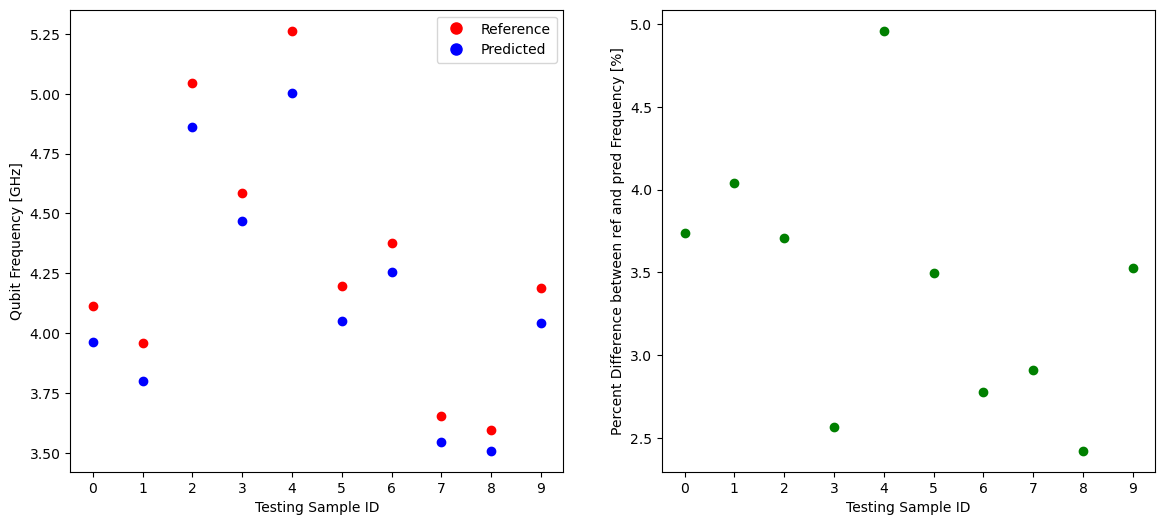

In [128]:
fig,ax = plt.subplots(1,2,figsize = (14,6))
Samples = simulation_results.Sample.to_numpy()

for sample in Samples:
    
    predicted_f = eval(simulation_results[simulation_results.Sample == sample].pred_H_params.iloc[0])["qubit_frequency_GHz"]
    reference_f = eval(simulation_results[simulation_results.Sample == sample].ref_H_params.iloc[0])["qubit_frequency_GHz"]

    diff_f = percentDiff(reference_f,predicted_f)
    
    ax[0].scatter([sample],[predicted_f],color = 'blue')
    ax[0].scatter([sample],[reference_f],color = 'red')
    ax[0].set_xticks(Samples,Samples)
    ax[0].set_xlabel("Testing Sample ID")
    ax[0].set_ylabel("Qubit Frequency [GHz]")
    
    ax[1].scatter([sample],[diff_f],color = 'green')
    ax[1].set_xticks(Samples,Samples)

    ax[1].set_xlabel("Testing Sample ID")
    ax[1].set_ylabel("Percent Difference between ref and pred Frequency [%]")


legend_elements = [
    Line2D([0], [0], marker='o', color='red',
           linestyle='None', markersize=8, label='Reference'),
    Line2D([0], [0], marker='o', color='blue',
           linestyle='None', markersize=8, label='Predicted'),
]

ax[0].legend(handles=legend_elements)

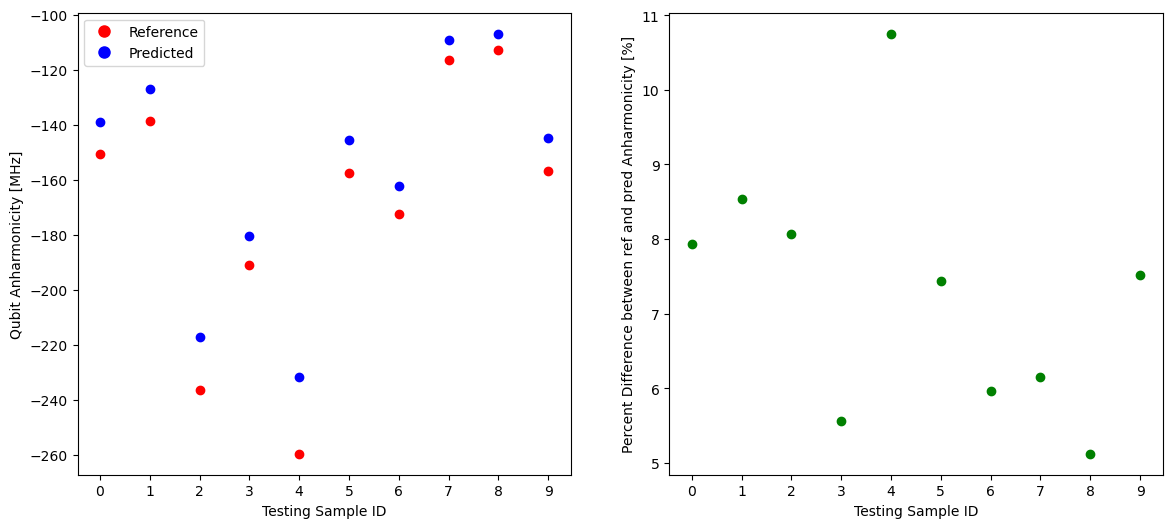

In [125]:
fig,ax = plt.subplots(1,2,figsize = (14,6))
Samples = simulation_results.Sample.to_numpy()

for sample in Samples:
    
    predicted_alpha = eval(simulation_results[simulation_results.Sample == sample].pred_H_params.iloc[0])["anharmonicity_MHz"]
    reference_alpha = eval(simulation_results[simulation_results.Sample == sample].ref_H_params.iloc[0])["anharmonicity_MHz"]

    diff_alpha = percentDiff(reference_alpha,predicted_alpha)
    
    ax[0].scatter([sample],[predicted_alpha],color = 'blue')
    ax[0].scatter([sample],[reference_alpha],color = 'red')
    ax[0].set_xticks(Samples,Samples)
    ax[0].set_xlabel("Testing Sample ID")
    ax[0].set_ylabel("Qubit Anharmonicity [MHz]")
    
    ax[1].scatter([sample],[diff_alpha],color = 'green')
    ax[1].set_xticks(Samples,Samples)

    ax[1].set_xlabel("Testing Sample ID")
    ax[1].set_ylabel("Percent Difference between ref and pred Anharmonicity [%]")


legend_elements = [
    Line2D([0], [0], marker='o', color='red',
           linestyle='None', markersize=8, label='Reference'),
    Line2D([0], [0], marker='o', color='blue',
           linestyle='None', markersize=8, label='Predicted'),
]

ax[0].legend(handles=legend_elements)